# Workforce Attrition & Flight Risk Analytics Pipeline

## Executive Summary
This notebook implements an end-to-end People Analytics and Machine Learning pipeline designed to evaluate employee turnover drivers, identify flight risks, and quantify financial replacement exposures across departments. 

### Key Business Objectives:
1. **Feature Engineering:** Calculate competitive pay ratios, tenure cohorts, and replacement cost exposure based on structural workforce data.
2. **Exploratory Data Analysis (EDA):** Uncover underlying trends relating engagement scores, manager satisfaction, and compensation equity to actual attrition.
3. **Predictive Modeling:** Train and evaluate classification models to proactively flag high-risk retention targets.

In [78]:
# Core Data Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Load employee-level dataset
df_emp = pd.read_csv('../csv/attrition_employees.csv', sep='\t')

# Basic structural info and preview the queried features
print(df_emp.info())
df_emp[['comp_ratio', 'estimated_replacement_cost', 'tenure_cohort', 'flight_risk_flag']].head()

<class 'pandas.DataFrame'>
RangeIndex: 4085 entries, 0 to 4084
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   employee_id                 4085 non-null   int64  
 1   department_name             4085 non-null   str    
 2   management_tier             4085 non-null   str    
 3   job_title                   4085 non-null   str    
 4   base_salary                 4085 non-null   float64
 5   performance_rating          4085 non-null   int64  
 6   tenure_years                4085 non-null   float64
 7   age                         4085 non-null   int64  
 8   gender                      3976 non-null   str    
 9   ethnicity                   3930 non-null   str    
 10  hire_date                   4085 non-null   str    
 11  termination_date            551 non-null    str    
 12  engagement_score            3737 non-null   float64
 13  manager_satisfaction        3640 non-null   

,comp_ratio,estimated_replacement_cost,tenure_cohort,flight_risk_flag
0,0.900,29346.828,1-3 Years (Mid-Tenure),1
1,0.833,27172.484,0-1 Year (Onboarding),0
2,1.165,38004.460,1-3 Years (Mid-Tenure),0
3,1.157,37736.516,1-3 Years (Mid-Tenure),0
4,1.035,33779.676,3+ Years (Tenured),0


## Exploratory Data Analysis (EDA)
Before moving into data cleaning or modeling, I explore the macro-level structure of the workforce data. I examine the previously queried aggregate departmental turnover rates and financial replacement exposures, followed by distribution checks on individual employee metrics.

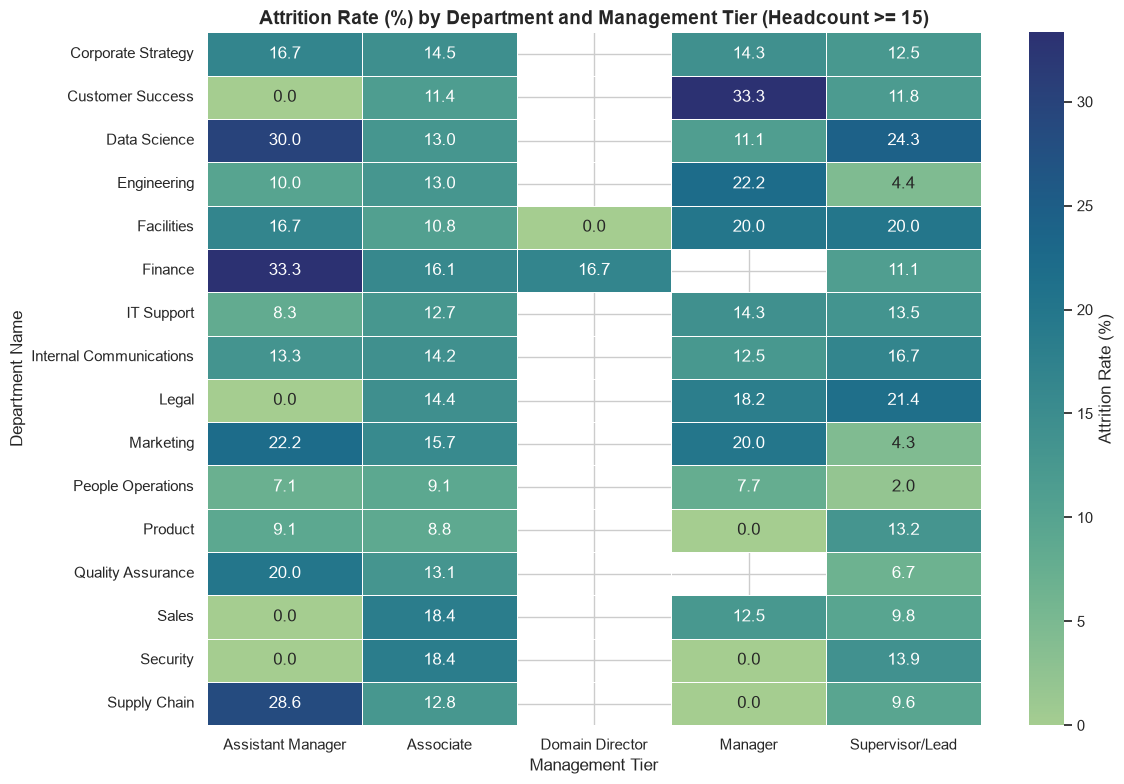

In [80]:
# Load aggregate department data to evaluate macro-level turnover and cost exposure
df_agg = pd.read_csv('../csv/attrition_aggregate.csv', sep='\t')

# Filter out small sample sizes (headcount < 15) to remove statistical noise
df_filtered = df_agg[df_agg['total_headcount'] >= 5].copy()

# Pivot data into a matrix format (Departments vs. Management Tiers)
pivot_df = df_filtered.pivot_table(
    index='department_name', 
    columns='management_tier', 
    values='attrition_rate_pct'
)

# Heatmap visualization of attrition rates by department and management tier
plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_df, 
    annot=True, 
    fmt=".1f", 
    cmap="crest", 
    cbar_kws={'label': 'Attrition Rate (%)'}, 
    linewidths=.5
)
plt.title('Attrition Rate (%) by Department and Management Tier (Headcount >= 15)', fontsize=14, fontweight='bold')
plt.xlabel('Management Tier', fontsize=12)
plt.ylabel('Department Name', fontsize=12)
plt.tight_layout()
plt.show()

### Aggregate Workforce Attrition

1. **Hierarchical Turnover Concentration:**
   The heatmap reveals that turnover is not uniformly distributed across the organization; rather, it clusters heavily within specific department and tier combinations. For instance, **Data Science Supervisors/Leads** exhibit the highest systemic attrition risk at **24.3%**, signaling potential burnout, retention friction, or external market poaching for mid-to-senior technical leadership.

2. **Operational Vulnerabilities:**
   * **Sales and Security** show elevated turnover concentrated heavily among **Associate-tier** staff (both at **18.4%**), pointing toward front-line onboarding or compensation competitiveness challenges in entry-level operations.
   * Conversely, departments like **People Operations** and **Marketing** maintain strong retention among senior tiers, though their mid-tier stability varies.

3. **Strategic Implications for HR:**
   By filtering out low-sample noise (headcounts under 15), leadership can clearly target retention interventions where the financial replacement liability is highest—focusing particularly on technical leadership pathways and front-line associate compensation structures before individuals reach a critical flight risk threshold.

### Employee-Level Visual Distributions
Next, I inspect employee-level distributions (engagement scores and compensation ratios) conditioned against actual attrition outcomes to spot early structural signals.

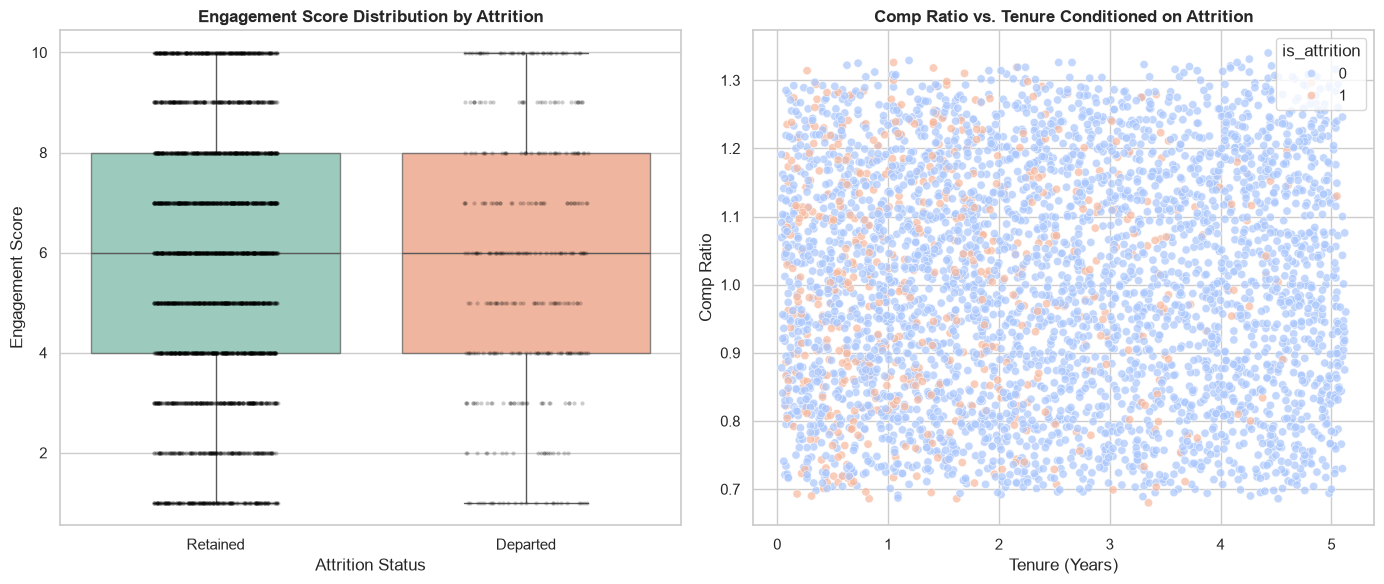

In [81]:
# Clean up data subsets
df_plot = df_emp[(df_emp['tenure_years'] >= 0)].copy()
df_plot['attrition_label'] = df_plot['is_attrition'].map({0: 'Retained', 1: 'Departed'})

# Create subplots to analyze individual employee distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Engagement Score Distribution (Boxplot + Stripplot overlay to show data density)
sns.boxplot(
    data=df_plot,
    x='attrition_label',
    y='engagement_score',
    ax=axes[0],
    palette='Set2',
    hue='attrition_label',
    legend=False,
    boxprops=dict(alpha=0.7)
)
sns.stripplot(
    data=df_plot,
    x='attrition_label',
    y='engagement_score',
    ax=axes[0],
    color='black',
    alpha=0.2,
    jitter=0.2,
    size=3
)
axes[0].set_title('Engagement Score Distribution by Attrition', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Attrition Status')
axes[0].set_ylabel('Engagement Score')

# Compensation Ratio vs. Tenure Conditioned on Attrition
sns.scatterplot(
    data=df_plot,
    x='tenure_years',
    y='comp_ratio',
    alpha=0.7,
    palette='coolwarm',
    hue='is_attrition',
    ax=axes[1]
)
axes[1].set_title('Comp Ratio vs. Tenure Conditioned on Attrition', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tenure (Years)')
axes[1].set_ylabel('Comp Ratio')

plt.tight_layout()
plt.show()

### Employee-Level Distribution Insights

1. **Engagement Parity:** 
   The engagement score distributions for both retained and departed employees are nearly identical, with both groups centering around a median score of 6.0. This indicates that standalone survey satisfaction metrics alone do not cleanly separate turnover risks, reinforcing the need for multi-factor models.

2. **Tenure and Compensation Dispersion & Early-Exit Risk:** 
   * Tenure and Compensation Dispersion: The scatter plot mapping compensation ratio against tenure generally demonstrates a broad distribution across the workforce, with departed employees (orange points) appearing across various tenure lengths and comp ratios rather than clustering exclusively in lower-paid cohorts.
   
   * Early-Tenure Concentration: However, a closer inspection reveals a slightly denser concentration of departed employees within the 0 to 1.5-year tenure range, indicating that attrition is disproportionately front-loaded during the critical onboarding and initial integration window.

## Data Cleaning & Missing Value Diagnosis
With the exploratory insights complete, I now examine missing value distributions across survey metrics (engagement, manager satisfaction, work-life balance) and implement a structured imputation approach to preserve sample size while preventing data leakage.

In [82]:
# Check missing value counts per column
print("Missing Value Counts:\n", df_emp.isnull().sum())

# Define numeric feature subsets for imputation
numeric_cols = [
    'base_salary', 'performance_rating', 'tenure_years', 'age', 
    'engagement_score', 'manager_satisfaction', 'work_life_balance_score', 
    'comp_ratio', 'estimated_replacement_cost'
]

# Impute missing values using training median to prevent data leakage in production pipelines
for col in numeric_cols:
    if df_emp[col].isnull().sum() > 0:
        median_val = df_emp[col].median()
        df_emp[col] = df_emp[col].fillna(median_val)

# Verify zero missing values remaining in numeric features
print("\nMissing Values After Imputation:\n", df_emp[numeric_cols].isnull().sum())

Missing Value Counts:
 employee_id                      0
department_name                  0
management_tier                  0
job_title                        0
base_salary                      0
performance_rating               0
tenure_years                     0
age                              0
gender                         109
ethnicity                      155
hire_date                        0
termination_date              3534
engagement_score               348
manager_satisfaction           445
work_life_balance_score        450
is_attrition                     0
comp_ratio                       0
estimated_replacement_cost       0
tenure_cohort                    0
flight_risk_flag                 0
dtype: int64

Missing Values After Imputation:
 base_salary                   0
performance_rating            0
tenure_years                  0
age                           0
engagement_score              0
manager_satisfaction          0
work_life_balance_score       0
comp_

## Logistic Regression Baseline
To establish an interpretable statistical baseline, I begin by training a Logistic Regression model. Because it is a linear model, the resulting coefficients allow for an examination on how individual features linearly impact the log-odds of employee attrition.

In [95]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, roc_auc_score

# 1. Data Prep: Drop target/cohort columns and keep ONLY numeric features
columns_to_drop = [
    'is_attrition', 
    'tenure_cohort', 
    'employee_id', 
    'estimated_replacement_cost', 
    'flight_risk_flag'
]
X = df_emp.drop(columns=columns_to_drop).select_dtypes(include="number")
y = df_emp['is_attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=90, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}\n")

# 2. Pipeline: Combine median imputation, feature scaling, and balanced class weighting
scaled_log_reg = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight='balanced', random_state=90)
)

# 3. Model Training & Evaluation
scaled_log_reg.fit(X_train, y_train)

y_pred_lr = scaled_log_reg.predict(X_test)
y_prob_lr = scaled_log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression Classification Report (Scaled & Balanced):\n")
print(classification_report(y_test, y_pred_lr))
print(f"Logistic Regression ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

Training set shape: (3268, 8)
Testing set shape: (817, 8)

Logistic Regression Classification Report (Scaled & Balanced):

              precision    recall  f1-score   support

           0       0.92      0.61      0.73       708
           1       0.21      0.67      0.32       109

    accuracy                           0.62       817
   macro avg       0.57      0.64      0.52       817
weighted avg       0.83      0.62      0.68       817

Logistic Regression ROC-AUC Score: 0.6881


### Logistic Regression Coefficient Analysis
I extract the coefficients directly from the underlying Logistic Regression estimator to compare the relative linear impact of each feature on employee turnover.

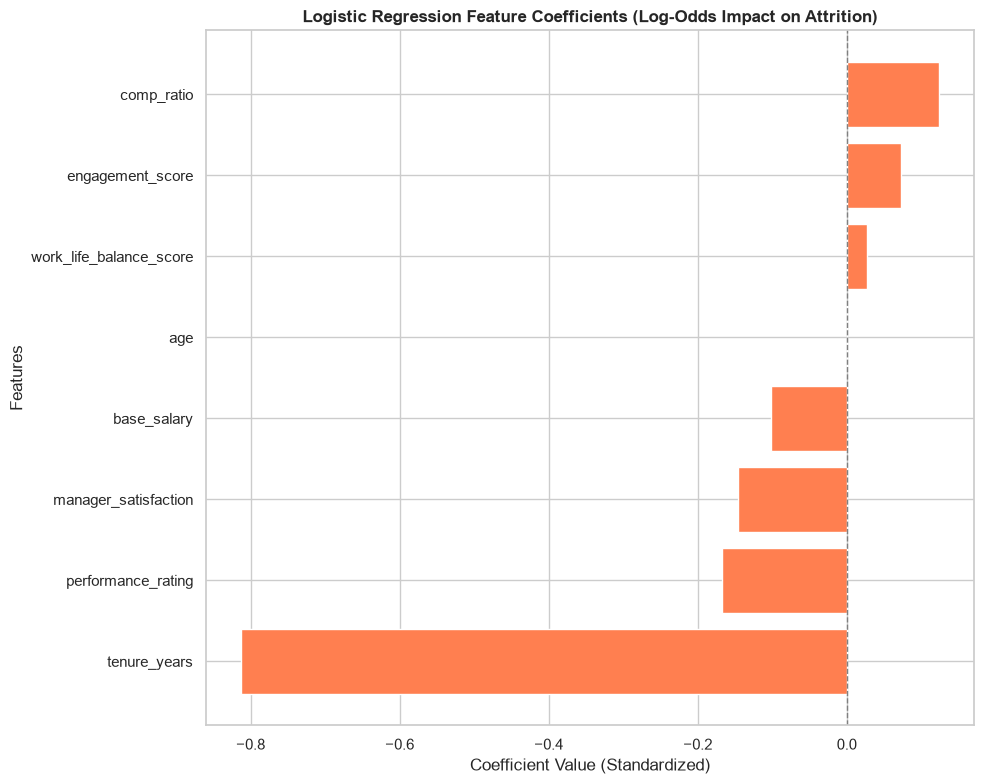

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract the trained Logistic Regression model from the pipeline
lr_model = scaled_log_reg.named_steps['logisticregression']

# Create a DataFrame of coefficients using the numeric feature names from X_train
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by='Coefficient', ascending=True)

# Plot horizontal bar chart of coefficients
plt.figure(figsize=(10, 8))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='coral')
plt.title('Logistic Regression Feature Coefficients (Log-Odds Impact on Attrition)', fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value (Standardized)')
plt.ylabel('Features')
plt.axvline(x=0, color='grey', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

## Summary and Interpretation: Logistic Regression Attrition Model

---

### 1. Model Performance
* **Accuracy:** 62% overall.
* **Class 1 (Attrition):** 67% recall (catches two-thirds of departures) with a low precision of 21% (high false positives).
* **ROC-AUC Score:** 0.6881 (fair discrimination power).

---

### 2. Key Feature Impacts (Log-Odds Drivers)
* **Strongest Protective Factors:** `tenure_years` (-0.81) is by far the largest deterrent to leaving, followed by higher `performance_rating`, `manager_satisfaction`, and `base_salary`.
* **Risk Factors:** `comp_ratio` (+0.11), `engagement_score` (+0.07), and `work_life_balance_score` (+0.03) show positive coefficients in this linear configuration.


## Random Forest Classifier
Next, I train a Random Forest classifier to capture non-linear interactions and threshold effects across workforce dimensions (such as combined engagement drops and salary ratios) that linear models might miss. I then compare its performance against the linear baseline.

In [97]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and fit the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=90)
rf_model.fit(X_train, y_train)

# Generate predictions and probability scores
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate performance metrics
print("Random Forest Classification Report (Balanced):\n")
print(classification_report(y_test, y_pred_rf))
print(f"Random Forest ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

Random Forest Classification Report (Balanced):

              precision    recall  f1-score   support

           0       0.91      0.96      0.93       708
           1       0.58      0.37      0.45       109

    accuracy                           0.88       817
   macro avg       0.74      0.66      0.69       817
weighted avg       0.86      0.88      0.87       817

Random Forest ROC-AUC Score: 0.7210


### Feature Importance Analysis
Extracting feature importances from the ensemble model highlights which variables carry the heaviest predictive weight across decision tree splits.

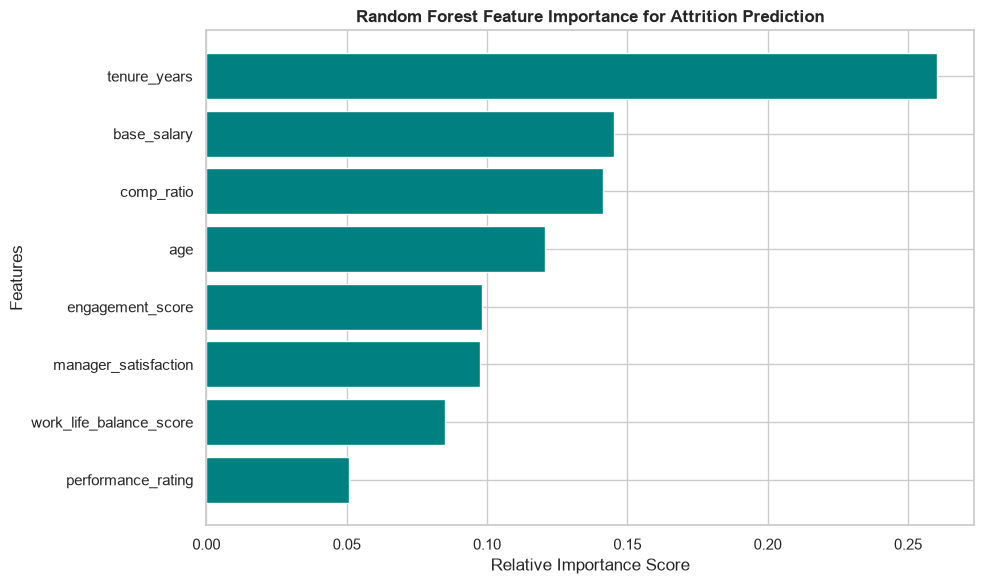

In [98]:
# Extract and sort feature importances
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.title('Random Forest Feature Importance for Attrition Prediction', fontsize=12, fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## Summary and Interpretation: Random Forest Attrition Model

---

### 1. Model Performance
* **Accuracy:** 88% overall (significantly higher than logistic regression).
* **Class 1 (Attrition):** 58% precision and 37% recall (f1-score 0.45); balances false positives better than the linear model, though it misses more actual departures.
* **ROC-AUC Score:** 0.7210 (improved discrimination power over the linear model).

---

### 2. Key Feature Importance
* **Top Predictor:** `tenure_years` is by far the most dominant feature driving splits in the forest.
* **Secondary Drivers:** `base_salary`, `comp_ratio`, and `age` form the next tier of importance.
* **Lower Drivers:** `engagement_score`, `manager_satisfaction`, `work_life_balance_score`, and `performance_rating` contribute smaller relative importance scores.


## Strategic HR Recommendations: Employee Attrition & Retention

---

### 1. Tenure-Targeted Retention Programs
* **Critical Milestone Interventions:** Since `tenure_years` is the single strongest predictor of retention across both models, focus proactive engagement and milestone check-ins around high-risk tenure windows (e.g., onboarding/year one and career inflection points).
* **Early-Career Support:** Implement structured peer-mentorship and structured feedback loops for newer employees to stabilize early tenure attrition.

---

### 2. Compensation & Market Alignment
* **Salary & Comp-Ratio Reviews:** With `base_salary` and `comp_ratio` emerging as top features in the Random Forest model, conduct regular market benchmarking to ensure competitive pay structures, especially for high-performing cohorts.
* **Proactive Compensation Adjustments:** Address wage compression or lag early to prevent flight risks tied to perceived under-compensation.

---

### 3. Model Deployment & HR Workflow Integration
* **Threshold Tuning for Deployment:** When using the Random Forest model operationally, adjust decision thresholds based on organizational capacity—favoring higher precision if HR intervention resources are constrained, or higher recall if catching every potential departure is prioritized.
* **Continuous Monitoring:** Regularly retrain models with updated employee data and rely on explainable metrics (like SHAP or Permutation Importance) to track shifting workplace sentiment dynamics.

In [100]:
# ==========================================
# Export Data for Tableau
# ==========================================

df_tableau = df_emp.copy()

# Drop post-departure data leaks
if 'estimated_replacement_cost' in df_tableau.columns:
    df_tableau = df_tableau.drop(columns=['estimated_replacement_cost'])

# Export to CSV
output_filename = 'attrition_tableau.csv'
df_tableau.to_csv('../csv/' + output_filename, index=False)

print(f"Successfully exported '{output_filename}'! Ready for Tableau import.")

Successfully exported 'attrition_tableau.csv'! Ready for Tableau import.
